Text(0.5, 1.0, 'Time vs Number of Processes')

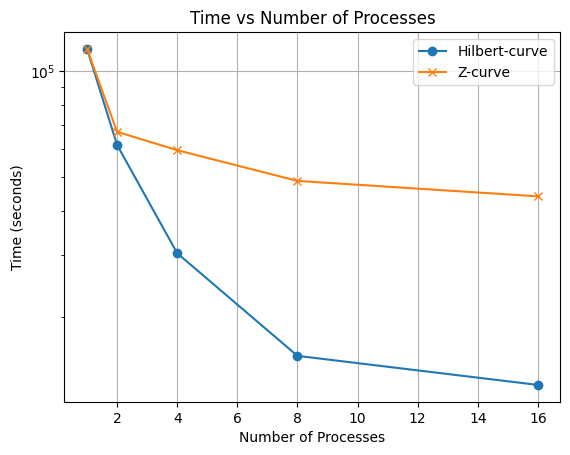

In [30]:
import matplotlib.pyplot as plt
import numpy as np
time = [32*3600, 61462, 30277, 15475, 12797]
time_slow = [32*3600, 67000, 16.5*3600,13.5*3600, 12.2*3600]
N =[1,2,4,8,16]

plt.semilogy(N, time, marker='o', label ="Hilbert-curve")
plt.semilogy(N, time_slow, marker='x', label='Z-curve')
plt.legend()
plt.xlabel('Number of Processes')
plt.ylabel('Time (seconds)')
plt.grid(True)
plt.title('Time vs Number of Processes')

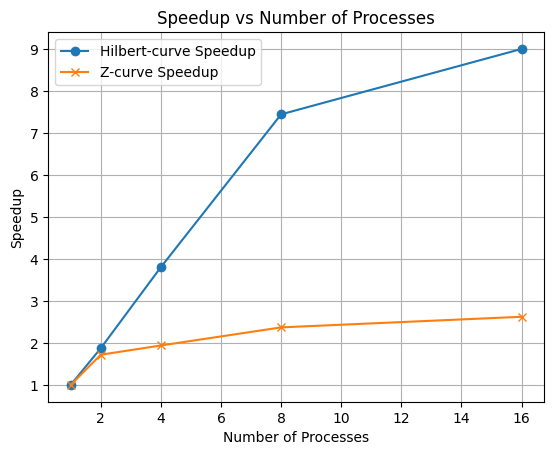

In [31]:
speedup = [time[0] / t for t in time]
speedup_slow = [time_slow[0] / t for t in time_slow]
plt.figure()
plt.plot(N, speedup, marker='o', label='Hilbert-curve Speedup')
plt.plot(N, speedup_slow, marker='x', label='Z-curve Speedup')
plt.legend()
plt.xlabel('Number of Processes')
plt.ylabel('Speedup')
plt.title('Speedup vs Number of Processes')
plt.grid(True)
plt.show()

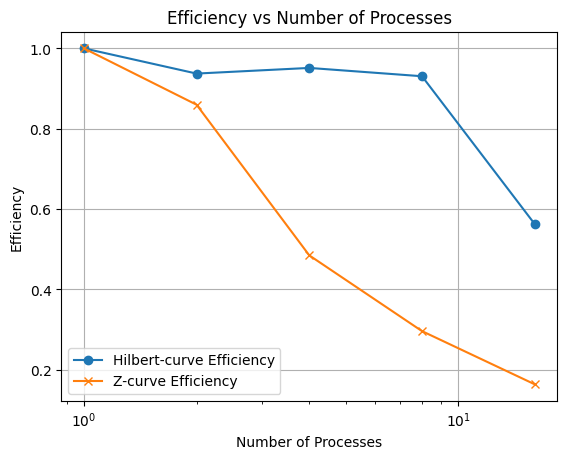

In [32]:
efficiency = [s / n for s, n in zip(speedup, N)]
efficiency_slow = [s / n for s, n in zip(speedup_slow, N)]
plt.figure()
plt.semilogx(N, efficiency, marker='o', label='Hilbert-curve Efficiency')
plt.semilogx(N, efficiency_slow, marker='x', label='Z-curve Efficiency')
plt.legend()
plt.xlabel('Number of Processes')
plt.ylabel('Efficiency')
plt.title('Efficiency vs Number of Processes')
plt.grid(True)
plt.show()

Estimated parallel fraction (P) from data: 0.9633
Estimated parallel fraction (P) from slow data: 0.7008


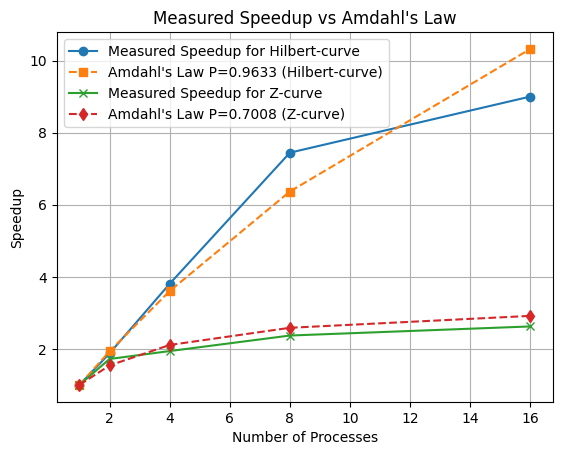

In [33]:

# Amdahl's Law: S(N) = 1 / ( (1-P) + P/N )
# Estimate P (parallel fraction) using measured speedup for each N

# Rearranged: P = (N/S - 1) / (N - 1)
P_estimates = [(n/s - 1)/(n-1) if n != 1 else 0 for n, s in zip(N, speedup)]
P_mean = 1 - np.mean(P_estimates[1:])  # exclude N=1 (serial case)

print(f"Estimated parallel fraction (P) from data: {P_mean:.4f}")

# Compute Amdahl's Law speedup curve using estimated P
N_range = np.array(N)
amdahl_speedup = 1 / ((1 - P_mean) + P_mean / N_range)

P_estimates_slow = [(n/s - 1)/(n-1) if n != 1 else 0 for n, s in zip(N, speedup_slow)]
P_mean_slow = 1 - np.mean(P_estimates_slow[1:])  # exclude N=1 (serial case)
print(f"Estimated parallel fraction (P) from slow data: {P_mean_slow:.4f}")
# Compute Amdahl's Law speedup curve using estimated P for slow data
amdahl_speedup_slow = 1 / ((1 - P_mean_slow) + P_mean_slow / N_range)

plt.figure()
plt.plot(N, speedup, 'o-', label='Measured Speedup for Hilbert-curve')
plt.plot(N_range, amdahl_speedup, 's--', label=f"Amdahl's Law P={P_mean:.4f} (Hilbert-curve)")
plt.plot(N, speedup_slow, 'x-', label='Measured Speedup for Z-curve')
plt.plot(N_range, amdahl_speedup_slow, 'd--', label=f"Amdahl's Law P={P_mean_slow:.4f} (Z-curve)")
plt.xlabel('Number of Processes')
plt.ylabel('Speedup')
plt.title("Measured Speedup vs Amdahl's Law")
plt.legend()
plt.grid(True)
plt.show()

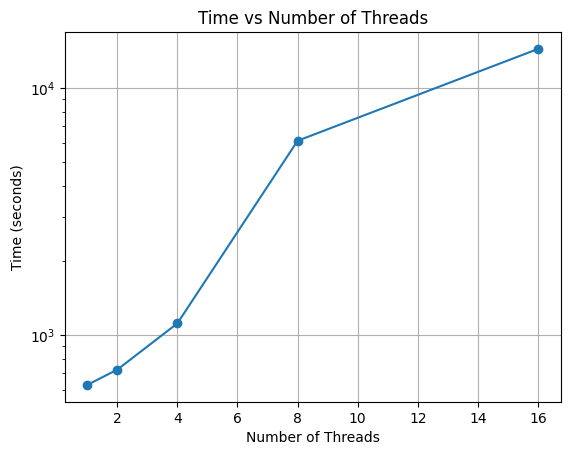

In [22]:
threads = [1, 2, 4, 8, 16]
time_threads = [629, 725,1116,1.7*3600, 4*3600]
plt.figure()
plt.semilogy(threads, time_threads, marker='o')
plt.xlabel('Number of Threads')
plt.ylabel('Time (seconds)')
plt.title('Time vs Number of Threads')
plt.grid(True)

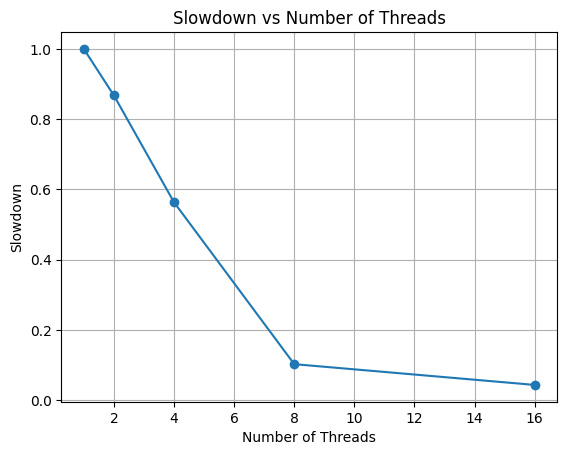

In [23]:
slow_down = [time_threads[0] / t for t in time_threads]

plt.figure()
plt.plot(threads, slow_down, marker='o')
plt.xlabel('Number of Threads')
plt.ylabel('Slowdown')
plt.title('Slowdown vs Number of Threads')
plt.grid(True)